# Artigo Induscon 2023

## Pre processamento

Pré-processamento dos dados de pesquisa no IEEE Xplore obtidos com os seguintes filtros:

- Search terms: "OPC UA"
- Language: English
- Date range: Last 5 years

#### Importação dos pacotes

In [67]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import os

%matplotlib inline

#### Preâmbulo

In [68]:
ROOT_DIR = os.path.abspath(os.path.join(os.curdir, '../../'))
input_path = os.path.join(ROOT_DIR, 'Build/Search1/Input')
output_path = os.path.join(ROOT_DIR, 'Build/Search1/Output')
img_path = os.path.join(output_path, 'Images')

# COLORS
grid_gray = '#E5E4E2'
warm1 = '#F94144'
warm2 = '#F3722C'
warm3 = '#F8961E'
warm4 = '#F9844A'
warm5 = '#F9C74F'
cold1 = '#90BE6D'
cold2 = '#43AA8B'
cold3 = '#4D908E'
cold4 = '#577590'
cold5 = '#277DA1'

#### Carregando as bases de dados

Base dos dados obtidos na primeira pesquisa já classificados.

In [69]:
# Set to True to filter for OPC UA keywords, False to skip filtering.
filter_by_opcua = True

# Load the initial dataframe
df = pd.read_excel(f'{input_path}/opcua5years_final.xlsm')

# Define columns to drop
drop_labels = ['Author Affiliations','Date Added To Xplore','Volume',
               'Issue','Start Page','End Page','ISSN','ISBNs','DOI',
               'Funding Information','PDF Link','INSPEC Controlled Terms',
               'INSPEC Non-Controlled Terms','Mesh_Terms','Article Citation Count',
               'Patent Citation Count','Reference Count','License','Online Date',
               'Issue Date','Meeting Date','Publisher']

# Create the initial classified dataframe
classified = df.drop(labels=drop_labels, axis=1)

# Perform your data transformations
classified['Category'] = list(classified['Category'].str.split(";", expand=False))
classified['Authors'] = list(classified['Authors'].str.split(";", expand=False))
classified.index += 2

# ---- Conditional Filtering Block ----
if filter_by_opcua:
    print("--- Filtering by OPC UA keywords is ON ---")
    # Define the regex pattern to find all variations
    regex_pattern = r'opc[\s:-]ua|opc unified architecture'

    # Filter using the regex pattern, ignoring case
    filtered_classified = classified[
        classified['Author Keywords'].str.contains(
            regex_pattern,
            case=False,      # Makes the search case-insensitive
            na=False,        # Handles empty keywords
            regex=True       # Ensures the pattern is treated as a regex
        )
    ].copy()
else:
    print("--- Filtering by OPC UA keywords is OFF ---")
    # If filtering is off, just use a copy of the original dataframe
    filtered_classified = classified.copy()


# Save the filtered dataframe and show info
# filtered_classified.to_csv(f'{output_path}/filtered_classified.csv',sep=',',encoding='UTF-8')
filtered_classified.info()
filtered_classified.tail()

--- Filtering by OPC UA keywords is ON ---
<class 'pandas.core.frame.DataFrame'>
Index: 339 entries, 2 to 471
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   Category             338 non-null    object
 1   Document Title       339 non-null    object
 2   Authors              339 non-null    object
 3   Publication Title    339 non-null    object
 4   Publication Year     339 non-null    object
 5   Abstract             339 non-null    object
 6   Author Keywords      339 non-null    object
 7   IEEE Terms           322 non-null    object
 8   Document Identifier  339 non-null    object
dtypes: object(9)
memory usage: 26.5+ KB


,Category,Document Title,Authors,Publication Title,Publication Year,Abstract,Author Keywords,IEEE Terms,Document Identifier
465,"[Product Development (PD), Performance Analysi...",Model-Based Co-Simulation Method for PLC Progr...,"[J. Lan, W. Zou, Q. Xu, Y. Lai, S. Zhu]",2024 IEEE 33rd International Symposium on Indu...,2024,The Industrial Internet of Things (IIoT) is an...,Programmable Logic Controller (PLC);co-simulat...,Adaptation models;Codes;Automation;Programmabl...,IEEE Conferences
466,"[Product Development (PD), Monitoring (M)]",Advances in the Smart Data Analytics Framework...,"[H. R. Mohan Rao, T. Chen, S. L. Shah]",2024 IEEE 3rd Industrial Electronics Society A...,2024,The efficient fusion of information from diffe...,Data analytics;Alarm systems;Performance monit...,Industries;Performance evaluation;Root cause a...,IEEE Conferences
467,"[Product Development (PD), Protocol Comparison...",Implementation of an Automated Pick and Place ...,"[M. C. Marica, N. Bizon, I. Bostan, F. M. E...",2024 16th International Conference on Electron...,2024,Industry 4.0 represents a significant evolutio...,Industry 4.0;Educational Platform;IO-Link;MQTT...,Industries;Training;System performance;Valves;...,IEEE Conferences
468,"[Theory(T), Product Development (PD)]",Integrated Management of Multi-Type Devices Th...,"[P. Li, Y. Liang, H. Li, Q. Xu, S. Zhu, C...",2024 IEEE 22nd International Conference on Ind...,2024,"In the era of Industry 4.0, the execution of i...",Sensing-computing-control integration;Informat...,Computational modeling;Knowledge graphs;Comput...,IEEE Conferences
471,"[Theory(T), Others (O)]",Realizing Consistent Digital Twins by Combinin...,"[A. Lüder, M. Schleipen, D. Hoffmann, J. Bl...",2024 IEEE 29th International Conference on Eme...,2024,Designing and utilizing digital twins is one o...,System lifecycle;Digital twin;Asset Administra...,Manufacturing industries;Production systems;Da...,IEEE Conferences


# Removido

> ISSO NÃO É MAIS NECESSÁRIO POR CONTA DO FILTRO APLICADO ACIMA

Base de dados obtida na segunda pesquisa, com os seguintes filtros:

- Search terms: "OPC UA" in Author Keywords
- Language: English
- Date range: Last 5 years

In [70]:
# df = pd.read_csv(f'{input_path}/opcua5years_keywords2.csv')
# new_query = df.drop(labels=drop_labels+['Authors','Publication Title','Publication Year','Abstract','Author Keywords','IEEE Terms','Document Identifier'], axis=1)
# new_query_titles = new_query['Document Title'].tolist()

Dataframe com a base de dados já classificada e filtrada para aquelas que apenas tem OPC UA no Author Keywords

In [71]:
# filtered_classified = classified[classified['Document Title'].isin(new_query_titles)]
# filtered_classified.to_csv(f'{output_path}/filtered_classified.csv',sep=',',encoding='UTF-8')
# filtered_classified.info()

Separação dos dados em categorias (EXPLODE)

In [72]:
def explode(df, lst_cols, fill_value='', preserve_index=False):
    if (lst_cols is not None
        and len(lst_cols) > 0
        and not isinstance(lst_cols, (list, tuple, np.ndarray, pd.Series))):
        lst_cols = [lst_cols]
    idx_cols = df.columns.difference(lst_cols)
    lens = df[lst_cols[0]].str.len()
    idx = np.repeat(df.index.values, lens)
    res = (pd.DataFrame({
                col:np.repeat(df[col].values, lens)
                for col in idx_cols},
                index=idx)
             .assign(**{col:np.concatenate(df.loc[lens>0, col].values)
                            for col in lst_cols}))
    if (lens == 0).any():
        res = (res.append(df.loc[lens==0, idx_cols], sort=False)
                  .fillna(fill_value))
    res = res.sort_index()
    if not preserve_index:
        res = res.reset_index(drop=True)
    return res

In [73]:
# classified_explode_categories = filtered_classified.explode('Category')
# classified_explode_categories['Category'].value_counts()
df_to_process = filtered_classified.copy()

# Stage 1: Prepare the column
df_to_process['Category'] = df_to_process['Category'].astype(str).fillna('')

# Stage 2: Initial Cleaning & Splitting
df_to_process['Category'] = df_to_process['Category'].str.strip('[]')
df_to_process['Category'] = df_to_process['Category'].str.split(',')

# Stage 3: Explode the list into separate rows
exploded_df = df_to_process.explode('Category')

# Stage 4: Clean individual strings
# First, strip whitespace AND single quotes from the ends.
exploded_df['Category'] = exploded_df['Category'].str.strip(" '")

# --- NEW STANDARDIZATION STEP ---
# Stage 5: Standardize spacing before parentheses
# This replaces "Category(X)" with "Category (X)" consistently.
exploded_df['Category'] = exploded_df['Category'].str.replace(r'\s*\(', ' (', regex=True)

# Stage 6: Filter out any remaining junk entries
# Removes any 'nan' strings or empty rows.
exploded_df = exploded_df[exploded_df['Category'].str.lower() != 'nan']
exploded_df = exploded_df[exploded_df['Category'] != '']

# Stage 7: Get the final, perfect counts
final_counts = exploded_df['Category'].value_counts()

print("--- Fully Cleaned and Aggregated Category Counts ---")
print(final_counts)

--- Fully Cleaned and Aggregated Category Counts ---
Category
Product Development (PD)            171
Others (O)                           82
Theory (T)                           76
Performance Analysis (PA)            59
Integration (I)                      57
Protocol Comparison (PC)             48
Monitoring (M)                       38
Wireless Communication (W)           33
Security (S)                         28
Diagnostic (D)                       12
Redundancy and Availability (RA)     10
Interoperability (I)                  1
Name: count, dtype: int64


## Consultas

Realizar as consultas na base para construir tabelas e gráficos da seção **Quantitative Analysis**

#### Número de publicações relacionadas com OPC UA por ano

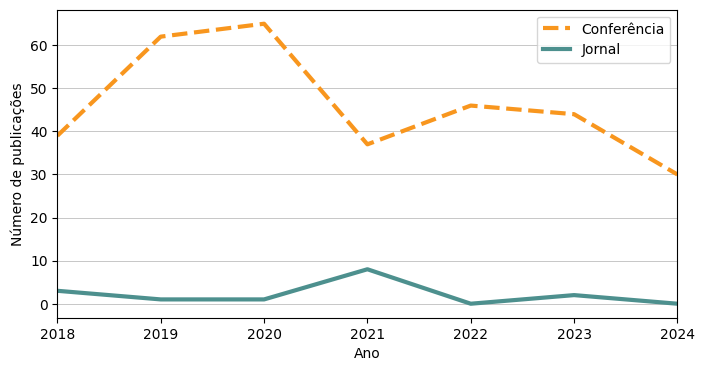

In [74]:
# grouped1 = filtered_classified.groupby(['Publication Year', 'Document Identifier']).size().reset_index(name='Count')
# pivot1 = grouped1.pivot(index='Publication Year', columns='Document Identifier', values='Count')
# plt.figure(figsize=(8, 4))
# # lines = pivot.plot(kind='line',linewidth=3)
# plt.plot(pivot1.index, pivot1['IEEE Conferences'], linestyle='--', color=warm2, linewidth=3, label='Conferência')
# plt.plot(pivot1.index, pivot1['IEEE Journals'], linestyle='-', color=cold2, linewidth=3, label='Jornal')
# plt.xlabel('Ano')
# plt.ylabel('Número de publicações')
# plt.xlim(2018, 2024)
# plt.xticks(range(2018, 2025, 1))
# plt.legend(title='', loc='upper right')
# plt.grid(axis = 'y', color=grid_gray, linewidth=0.5)
# plt.savefig(f'{img_path}/pubPerYear.png', format='png', dpi=600)
# plt.show()
df_to_plot = filtered_classified.copy()
# --- STANDARDIZATION STEP ---
# 1. Define the conditions for your categories using .str.contains()
#    'case=False' makes it case-insensitive.
is_conference = df_to_plot['Document Identifier'].str.contains('Conferences', case=False, na=False)
is_journal = df_to_plot['Document Identifier'].str.contains('Journals', case=False, na=False)

# 2. Create a list of conditions and corresponding choices
conditions = [is_conference, is_journal]
choices = ['Conference', 'Journal']

# 3. Use np.select to create the new 'Publication Type' column
#    If neither condition is met, it will be labeled 'Other'.
df_to_plot['Publication Type'] = np.select(conditions, choices, default='Other')

# 4. Filter out any rows that didn't match 'Conference' or 'Journal'
df_to_plot = df_to_plot[df_to_plot['Publication Type'] != 'Other']


# --- PLOTTING WITH THE NEW COLUMN ---
# 5. Group by the new, clean 'Publication Type' column
counts_df = df_to_plot.groupby(['Publication Year', 'Publication Type']).size().reset_index(name='Count')

# 6. Pivot the data
pivot_df = counts_df.pivot(index='Publication Year', columns='Publication Type', values='Count')

# 7. Fill missing values with 0 for a clean plot
pivot_df = pivot_df.fillna(0)

# 8. Create the plot using the standardized column names
plt.figure(figsize=(8, 4))
# Ensure the columns exist before trying to plot them
if 'Conference' in pivot_df.columns:
    plt.plot(pivot_df.index, pivot_df['Conference'], linestyle='--', linewidth=3, color=warm3, label='Conferência')
if 'Journal' in pivot_df.columns:
    plt.plot(pivot_df.index, pivot_df['Journal'], linestyle='-', linewidth=3, color=cold3, label='Jornal')

plt.xlabel('Ano')
plt.ylabel('Número de publicações')
plt.xlim(2018, 2024)
plt.xticks(range(2018, 2025, 1))
plt.legend(title='', loc='upper right')
plt.grid(axis='y', linewidth=0.5)
plt.savefig(f'{img_path}/pubPerYear.png', format='png', dpi=600)
plt.show()

Total de artigos em conferência e jornal

In [75]:
# Calculate the total sum for each standardized category from the correct DataFrame
total_conferences = pivot_df['Conference'].sum()
total_journals = pivot_df['Journal'].sum()

print(f"Total de Publicações em Conferências: {total_conferences}")
print(f"Total de Publicações em Jornais: {total_journals}")

Total de Publicações em Conferências: 323.0
Total de Publicações em Jornais: 15.0


Nomes dos jornais

In [76]:
# Create a boolean mask to find all entries identified as journals.
is_journal = filtered_classified['Document Identifier'].str.contains('Journals', case=False, na=False)

# Apply the filter and get the counts for each unique 'Publication Title'.
journal_counts = filtered_classified[is_journal]['Publication Title'].value_counts()

# Print the results
print("--- Contagem por Título de Jornal ---")
print(journal_counts)

--- Contagem por Título de Jornal ---
Publication Title
IEEE Access                                                         11
IEEE Transactions on Industrial Informatics                          1
IEEE Transactions on Very Large Scale Integration (VLSI) Systems     1
IEEE Transactions on Instrumentation and Measurement                 1
Proceedings of the IEEE                                              1
Name: count, dtype: int64


Maior meio publicador

In [77]:
# Padrão de regex para extrair o texto dentro do primeiro par de parênteses
pattern = r'\((.*?)\)'

# --- 1. Maior publicador geral ---
all_publishers = filtered_classified['Publication Title'].str.extract(pattern, expand=False)
all_counts = all_publishers.value_counts()
# Pega o nome e a quantidade do mais frequente
top_publisher_geral_nome = all_counts.index[0]
top_publisher_geral_qtd = all_counts.iloc[0]


# --- 2. Maior publicador de jornais ---
filtro_jornais = filtered_classified['Document Identifier'].str.contains('Journals', case=False, na=False)
publicadores_jornais = filtered_classified[filtro_jornais]['Publication Title'].str.extract(pattern, expand=False)
journal_counts = publicadores_jornais.value_counts()
# Pega o nome e a quantidade do mais frequente
top_publisher_jornal_nome = journal_counts.index[0]
top_publisher_jornal_qtd = journal_counts.iloc[0]


# --- 3. Maior publicador de conferências ---
filtro_conferencias = filtered_classified['Document Identifier'].str.contains('Conferences', case=False, na=False)
publicadores_conferencias = filtered_classified[filtro_conferencias]['Publication Title'].str.extract(pattern, expand=False)
conference_counts = publicadores_conferencias.value_counts()
# Pega o nome e a quantidade da mais frequente
top_publisher_conferencia_nome = conference_counts.index[0]
top_publisher_conferencia_qtd = conference_counts.iloc[0]


# --- Resultados Finais com Quantidades ---
print(f"O maior meio publicador (geral) foi: {top_publisher_geral_nome} (com {top_publisher_geral_qtd} publicações)")
print(f"Dos jornais, o maior foi: {top_publisher_jornal_nome} (com {top_publisher_jornal_qtd} publicações)")
print(f"Das conferências, a maior foi: {top_publisher_conferencia_nome} (com {top_publisher_conferencia_qtd} publicações)")

O maior meio publicador (geral) foi: ETFA (com 64 publicações)
Dos jornais, o maior foi: VLSI (com 1 publicações)
Das conferências, a maior foi: ETFA (com 64 publicações)


Escritores com maior quantidade de publicações

In [78]:
# 1. Usa .explode() para criar uma linha para cada autor em cada publicação.
#    .dropna() remove qualquer entrada que possa não ter autores.
exploded_authors_df = filtered_classified.explode('Authors').dropna(subset=['Authors'])

# 2. Limpa os nomes para remover espaços em branco no início ou fim.
cleaned_authors = exploded_authors_df['Authors'].str.strip()

# 3. Conta as publicações por autor com .value_counts().
#    O resultado já vem ordenado do maior para o menor.
author_counts = cleaned_authors.value_counts()

# 4. Seleciona os 5 primeiros da lista.
top_5_authors = author_counts.head(5)

# Imprime o resultado
print("--- Top 5 Autores com Mais Publicações ---")
print(top_5_authors)

--- Top 5 Autores com Mais Publicações ---
Authors
V. Vyatkin       10
W. Kastner        9
U. D. Atmojo      8
T. FrÃ¼hwirth     8
L. Wisniewski     7
Name: count, dtype: int64


#### Quantidade de artigos por categorias (Tabela)

In [79]:
# We'll use the 'exploded_df' DataFrame from the previous cleaning steps.
df_para_limpeza = exploded_df.copy()

# --- ETAPA DE LIMPEZA DO ANO DE PUBLICAÇÃO ---
# 1. Converte a coluna para um tipo numérico.
#    O parâmetro 'errors='coerce'' transforma qualquer valor não numérico
#    (como 'NA' ou 'ISR Europe 2023') em NaN (Not a Number).
df_para_limpeza['Publication Year'] = pd.to_numeric(df_para_limpeza['Publication Year'], errors='coerce')

# 2. Remove as linhas onde a conversão falhou (onde o ano agora é NaN).
df_para_limpeza = df_para_limpeza.dropna(subset=['Publication Year'])

# 3. Converte a coluna de ano para inteiro para uma exibição limpa.
df_para_limpeza['Publication Year'] = df_para_limpeza['Publication Year'].astype(int)


# --- Agora, prossiga com a lógica de agrupamento e pivô ---
# 4. Agrupa os dados limpos por ano e categoria.
contagem_por_categoria = df_para_limpeza.groupby(['Publication Year', 'Category']).size().reset_index(name='Count')

# 5. Pivota a tabela.
tabela_pivot = contagem_por_categoria.pivot(
    index='Publication Year', 
    columns='Category', 
    values='Count'
)

# 6. Preenche os valores restantes com 0 e converte para inteiro.
tabela_pivot_final = tabela_pivot.fillna(0).astype(int)

# Exibe a tabela final e limpa
tabela_pivot_final

Category,Diagnostic (D),Integration (I),Interoperability (I),Monitoring (M),Others (O),Performance Analysis (PA),Product Development (PD),Protocol Comparison (PC),Redundancy and Availability (RA),Security (S),Theory (T),Wireless Communication (W)
Publication Year,,,,,,,,,,,,
2018,3,10,0,2,8,6,22,3,2,3,2,1
2019,3,13,0,7,16,10,33,10,1,6,6,8
2020,4,14,0,11,20,8,26,12,3,5,8,7
2021,0,11,1,3,3,12,25,7,1,4,5,7
2022,1,8,0,4,10,8,28,8,2,5,5,4
2023,1,1,0,9,16,9,24,2,0,1,33,5
2024,0,0,0,2,9,6,13,6,1,4,17,1


Coexistência de categorias

In [80]:
#